In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import glob
import os
from features_xtraction import features_extraction
from elbow_kmeans import elbow_kmeans
from sklearn.cluster import KMeans
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from phase_probability import phase_probability

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

Preparing the data. 

In [3]:
# Making a dataframe. Here, every column represent a ECC in a timestep of the domain.
os.chdir('/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/Data/ECC')

path = r'/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/Data/ECC'

dataframe = pd.DataFrame()

#Going through every file in "dir".
for file in os.listdir(path):

    temp = pd.read_csv(file, header=None, sep=",").T
    
    dataframe = dataframe.append(temp)

# Transposing the dataframe.
dataframe = dataframe.T

# Adding a index row.
dataframe.columns=range(0,864)

/tmp/ipykernel_5757/1360943965.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dataframe = dataframe.append(temp)
/tmp/ipykernel_5757/1360943965.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dataframe = dataframe.append(temp)
/tmp/ipykernel_5757/1360943965.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dataframe = dataframe.append(temp)
/tmp/ipykernel_5757/1360943965.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dataframe = dataframe.append(temp)
/tmp/ipykernel_5757/1360943965.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instea

/tmp/ipykernel_5757/1360943965.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dataframe = dataframe.append(temp)
/tmp/ipykernel_5757/1360943965.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dataframe = dataframe.append(temp)
/tmp/ipykernel_5757/1360943965.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dataframe = dataframe.append(temp)
/tmp/ipykernel_5757/1360943965.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dataframe = dataframe.append(temp)
/tmp/ipykernel_5757/1360943965.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instea

/tmp/ipykernel_5757/1360943965.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dataframe = dataframe.append(temp)
/tmp/ipykernel_5757/1360943965.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dataframe = dataframe.append(temp)
/tmp/ipykernel_5757/1360943965.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dataframe = dataframe.append(temp)
/tmp/ipykernel_5757/1360943965.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dataframe = dataframe.append(temp)
/tmp/ipykernel_5757/1360943965.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instea

/tmp/ipykernel_5757/1360943965.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dataframe = dataframe.append(temp)
/tmp/ipykernel_5757/1360943965.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dataframe = dataframe.append(temp)
/tmp/ipykernel_5757/1360943965.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dataframe = dataframe.append(temp)
/tmp/ipykernel_5757/1360943965.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dataframe = dataframe.append(temp)
/tmp/ipykernel_5757/1360943965.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instea

In [4]:
# Extrancting some statistical features from the dataframe
# This features are: *Mean *Variance *Autocorrelation
#                    *Nº of peaks with value grater than 2
#                    *Entropy
features_dataframe=features_extraction(dataframe)

/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_i

/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_i

/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_i

/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_i

/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_i

...

/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_i

/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_i

/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_i

/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_i

/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_i

In [6]:
features_dataframe

,lumpiness,ACF1,lshift,vchange,cpoints,fspots,trend,linearity,curvature,spikiness,boxcox,Mean,Variance,Nº peaks,Entropy
0,0.002152,0.921675,0.500000,0.069444,8.0,70.0,0.000000,0.021597,2.257473,2.151313e-07,0.941747,0.569767,0.373039,2.0,0.090256
0,0.000778,0.968399,0.375000,0.047917,2.0,120.0,0.437608,0.008374,1.462751,3.140123e-07,0.442262,0.569767,0.373039,2.0,0.090256
0,0.000262,0.930412,0.333333,0.030864,6.0,86.0,0.000000,0.013957,1.951102,6.289673e-08,0.792420,0.569767,0.373039,2.0,0.090256
0,0.000550,0.937028,0.500000,0.069444,6.0,69.0,0.000000,0.022037,2.054761,1.387621e-07,0.949507,0.569767,0.373039,2.0,0.090256
0,0.000430,0.930399,0.250000,0.017361,4.0,92.0,0.000000,0.010027,1.383470,1.035461e-07,0.612629,0.569767,0.373039,2.0,0.090256
0,0.000222,0.844280,0.325000,0.041667,6.0,119.0,0.300250,0.007383,1.373104,1.022467e-07,0.588193,0.569767,0.373039,2.0,0.090256
0,0.000651,0.882734,0.333333,0.030864,6.0,84.0,0.000000,0.012488,1.425894,8.994274e-08,0.720054,0.569767,0.373039,2.0,0.090256
0,0.000884,0.940680,0.500000,0.069444,4.0,72.0,0.000000,0.020054,1.999092,1.504063e-07,1.033403,0.569767,0.373039,2.0,0.090256
0,0.000759,0.930857,0.533333,0.074074,4.0,122.0,0.407385,0.008962,1.636284,2.181461e-07,0.581419,0.569767,0.373039,2.0,0.090256
0,0.000226,0.932836,0.566667,0.100000,10.0,111.0,0.019221,0.011166,1.838740,1.246391e-07,0.662243,0.569767,0.373039,2.0,0.090256


Clusterization. 

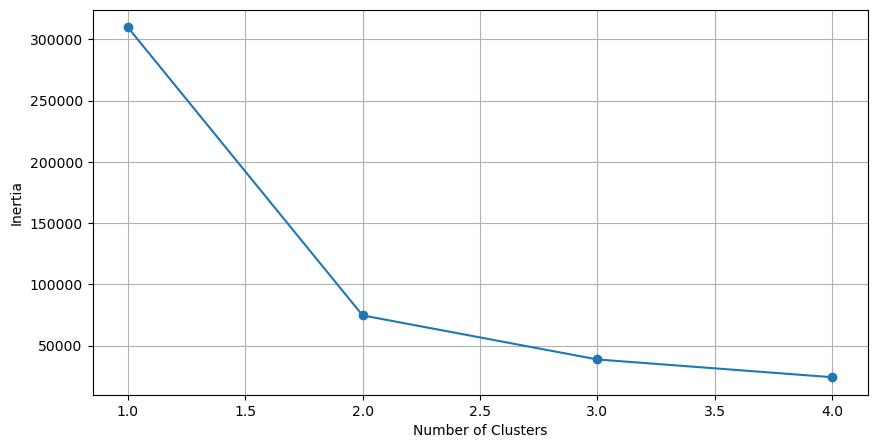

In [7]:
# Computing the optimum number of cluster and visualizing it.
elbow_kmeans(features_dataframe, 5)

In [8]:
# Going through the clusterization.
kmeans = KMeans(n_clusters=3)
kmeans.fit(features_dataframe)

KMeans(n_clusters=3)

In [9]:
# Adding a column to the feature dataframe related to the custerization labels.
features_dataframe['kmeans_3'] = kmeans.labels_

Getting the labels indexes. 

In [10]:
label_0 = [i for i, val in enumerate(features_dataframe['kmeans_3'] == 0) if val]

In [11]:
label_1 = [i for i, val in enumerate(features_dataframe['kmeans_3'] == 1) if val]

In [12]:
label_2 = [i for i, val in enumerate(features_dataframe['kmeans_3'] == 2) if val]

Ploting the clusters. 

Text(0, 0.5, 'EC')

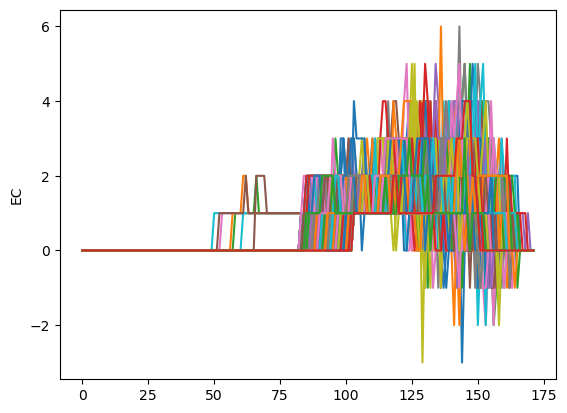

In [13]:
for i in range(1, len(label_0)):
    plt.plot(range(0,172), dataframe[label_0[i]])
plt.ylabel("EC")

Text(0, 0.5, 'EC')

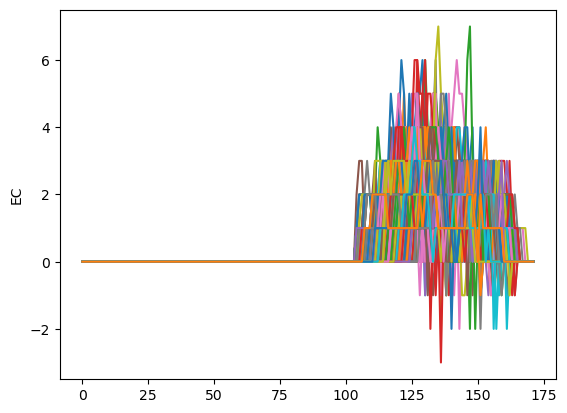

In [14]:
for i in range(1, len(label_1)):
    plt.plot(range(0,172), dataframe[label_1[i]])
plt.ylabel("EC")

Text(0, 0.5, 'EC')

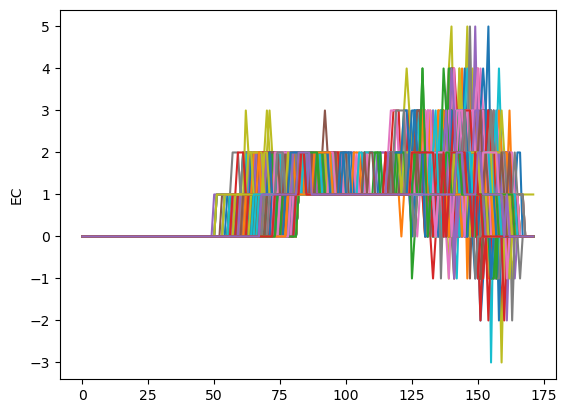

In [15]:
for i in range(1, len(label_2)):
    plt.plot(range(0,172), dataframe[label_2[i]])
plt.ylabel("EC")

Computing the matching of each cluester label with the ONI index.

In [16]:
#---------------------First, some paperwork.-------------------------------

In [17]:
cd ..

/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/Data


In [18]:
ENSO_indexes = pd.read_csv('ENSO.csv', header=None, sep=",")[3]

In [19]:
#----------------------------------//--------------------------------------

In [20]:
phase_probability(ENSO_indexes[label_0].tolist())

Probability of neutral phase: 50 %
Probability of Ninha  phase: 27 %
Probability of Ninho phase: 24 %


[50, 27, 24]

In [21]:
phase_probability(ENSO_indexes[label_1].tolist())

Probability of neutral phase: 49 %
Probability of Ninha  phase: 25 %
Probability of Ninho phase: 26 %


[49, 25, 26]

In [22]:
phase_probability(ENSO_indexes[label_2].tolist())

Probability of neutral phase: 41 %
Probability of Ninha  phase: 30 %
Probability of Ninho phase: 29 %


[41, 30, 29]

Displaying a ONI index dataframe. 

In [23]:
aux = np.array(pd.DataFrame(ENSO_indexes).T)
oni=pd.DataFrame(aux[0][0:864].reshape(-1, 12)).T
oni.columns = range(1950,2022)
oni = oni.T
oni.columns=['DJF', 'JFM', 'FMA', 'MAM', 'AMJ', 'MJJ', 'JJA', 'JAS', 'ASO', 'SON', 'OND','NDJ']

In [24]:
oni

,DJF,JFM,FMA,MAM,AMJ,MJJ,JJA,JAS,ASO,SON,OND,NDJ
1950,1,1,1,1,1,1,1,0,0,0,0,0
1951,0,0,0,0,0,2,2,2,2,2,2,2
1952,2,0,0,0,0,0,0,0,0,0,0,0
1953,0,2,2,2,2,2,2,2,2,2,2,2
1954,2,2,0,0,1,1,1,1,1,1,1,1
1955,1,1,1,1,1,1,1,1,1,1,1,1
1956,1,1,1,1,1,1,1,1,1,0,0,0
1957,0,0,0,2,2,2,2,2,2,2,2,2
1958,2,2,2,2,2,2,2,0,0,0,2,2
1959,2,2,2,0,0,0,0,0,0,0,0,0
